# Batch-Adjustment Mean Shift Analysis

How much does treating batch as a confounder shift the estimated perturbation effect?

Two contrasts are computed for each perturbation T (restricted to the common batch support
S_{t,0} = S_t ∩ S_0):

| Estimate | Formula | Note |
|---|---|---|
| **Naive** | E[Y\|T] − E[Y\|ctrl] | Marginalises over the treatment-specific batch distribution |
| **Adjusted** | Σ_b p(B=b) [μ(T,b) − μ(ctrl,b)] | Treats batch as a confounder; marginalises over the *population* p(B) |

The **delta** = naive − adjusted captures the shift induced by batch confounding.

To remove shifts that affect even non-targeted genes (background batch bias), we
**centre each perturbation row by subtracting the mean delta over control genes** —
highly-variable genes not targeted by any perturbation.

Finally, the **per-perturbation RMS norm** of the centred delta reveals which perturbations
are most affected by batch confounding.

In [1]:
import numpy as np
import pandas as pd
pd.options.future.infer_string = False
import pertpy as pt
import scanpy as sc
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.sparse import issparse

In [2]:
def load_and_preprocess(
    n_top_genes: int = 5000,
    target_sum: float = 4000.0,
    min_counts: int = 100,
    min_cells: int = 5,
) -> sc.AnnData:
    adata = pt.data.replogle_2022_k562_essential()
    sc.pp.filter_cells(adata, min_counts=min_counts)
    sc.pp.filter_genes(adata, min_cells=min_cells)
    sc.pp.normalize_total(adata, target_sum=target_sum)
    sc.pp.log1p(adata)
    sc.pp.highly_variable_genes(adata, n_top_genes=n_top_genes, subset=True)
    # Ensure perturbed genes are always included even if not highly variable
    perturbed_genes = set(adata.obs["perturbation"].unique()) - {"control"}
    adata.var["highly_variable"] |= adata.var_names.isin(perturbed_genes)
    adata = adata[:, adata.var["highly_variable"]].copy()
    return adata[(adata.obs["nperts"] == 1) | (adata.obs["perturbation"] == "control")].copy()

## Model

`PerturbationModel` fits empirical per-condition, per-batch means and exposes `predict_contrast`
which returns both the naive (observational) and adjusted (interventional) contrasts for any
perturbation/control pair.

`evaluate` loops over all perturbations and stacks the deltas into an `(n_perts, n_genes)` matrix.

In [3]:
class PerturbationModel:
    """Empirical group means with batch marginalisation.

    Two contrasts, both restricted to common batch support S_{t,0} = S_t ∩ S_0:

      unadjusted:  Σ_{b} p(b|t) μ(t,b)  −  Σ_{b} p(b|0) μ(0,b)   [observational]
      adjusted:    Σ_{b} p(B=b)[μ(t,b)  −  μ(0,b)]                 [interventional]

    The adjusted estimate treats batch as a confounder and marginalises over the
    population batch distribution p(B), breaking the association between treatment
    and batch assignment.
    """

    def __init__(self, condition_key: str = "perturbation", batch_key: str = "batch"):
        self.ck = condition_key
        self.bk = batch_key

    def fit(self, adata: sc.AnnData) -> "PerturbationModel":
        Y = adata.X.toarray() if issparse(adata.X) else np.array(adata.X)
        tb = adata.obs[[self.ck, self.bk]].copy()
        tb["_pos"] = np.arange(len(tb))
        self._means = {
            (t, b): Y[grp["_pos"].values].mean(axis=0)
            for (t, b), grp in tb.groupby([self.ck, self.bk])
        }
        obs = adata.obs
        self._p_B = obs[self.bk].value_counts(normalize=True).sort_index()
        self._p_B_given_T = (
            obs.groupby([self.ck, self.bk]).size()
            .div(obs.groupby(self.ck).size(), level=self.ck)
        )
        return self

    def predict_contrast(self, pert: str, ctrl: str = "control") -> tuple[np.ndarray, np.ndarray]:
        """Return (unadjusted, adjusted) contrasts over S_{t,0} = S_t ∩ S_0."""
        S_t = set(self._p_B_given_T.loc[pert].index)
        S_0 = set(self._p_B_given_T.loc[ctrl].index)
        # Set of batches where both pert and ctrl appear.
        # ctlr appears in all batches so this is just S_t, but we check to be sure.
        common = sorted(S_t & S_0)
        if not common:
            raise ValueError(f"No common batches between '{pert}' and '{ctrl}'")

        mu_t = np.stack([self._means[(pert, b)] for b in common])
        mu_0 = np.stack([self._means[(ctrl, b)] for b in common])

        w_t = self._p_B_given_T.loc[pert].reindex(common).fillna(0.0).values.copy()
        # Reweight in case some batches are missing for this pert, so that we only consider the common support.
        w_t = w_t / w_t.sum()
        w_0 = self._p_B_given_T.loc[ctrl].reindex(common).fillna(0.0).values.copy()
        w_0 = w_0 / w_0.sum()
        w_int = self._p_B.reindex(common).fillna(0.0).values.copy()
        w_int = w_int / w_int.sum()
        unadjusted = w_t @ mu_t - w_0 @ mu_0
        adjusted   = w_int @ (mu_t - mu_0)
        return unadjusted, adjusted

In [4]:
def evaluate(
    model: PerturbationModel,
    adata: sc.AnnData,
    condition_key: str = "perturbation",
    ctrl_label: str = "control",
) -> tuple[np.ndarray, list[str]]:
    """Return (delta_matrix, pert_names).

    delta_matrix[i, j] = unadjusted[j] - adjusted[j] for perturbation i, where:
      unadjusted = E[Y|T] - E[Y|ctrl]              (conditional on batch)
      adjusted = Σ_b p(B=b)[μ(T,b) - μ(ctrl,b)] (do operator on T, marginalise over B)
    """
    obs, int, deltas, pert_names = [], [], [], []
    for pert in sorted(adata.obs[condition_key].unique()):
        if pert == ctrl_label:
            continue
        cells = adata[adata.obs[condition_key] == pert]
        if len(cells) == 0:
            continue
        unadjusted, adjusted = model.predict_contrast(pert, ctrl_label)
        obs.append(unadjusted)
        int.append(adjusted)
        deltas.append(unadjusted - adjusted)
        pert_names.append(pert)

    return np.stack(deltas), np.stack(obs), np.stack(int), pert_names

## Data

Replogle 2022 K562 essential gene screen. Preprocessed once and cached to disk.

In [5]:
_data_dir = next((p for p in [Path("data"), Path("../data")] if p.is_dir()), None)
if _data_dir is None:
    raise FileNotFoundError(f"Cannot locate data/ directory from CWD: {Path.cwd()}")
PREPROCESSED_PATH = _data_dir / "replogle_k562_preprocessed.h5ad"


def _try_load(path: Path) -> sc.AnnData | None:
    try:
        adata = sc.read_h5ad(path)
        assert "perturbation" in adata.obs.columns
        return adata
    except Exception as e:
        print(f"Cached file invalid ({e}); deleting and reprocessing…")
        path.unlink(missing_ok=True)
        return None


adata = _try_load(PREPROCESSED_PATH) if PREPROCESSED_PATH.exists() else None
if adata is None:
    adata = load_and_preprocess()
    adata.write_h5ad(PREPROCESSED_PATH, compression="gzip")
    print(f"Saved to {PREPROCESSED_PATH}")
else:
    print(f"Loaded from {PREPROCESSED_PATH}")
print(f"  {adata.n_obs:,} cells  ×  {adata.n_vars:,} genes  |  {adata.obs['perturbation'].nunique():,} perturbations")

Loaded from data/replogle_k562_preprocessed.h5ad
  310,385 cells  ×  5,000 genes  |  2,058 perturbations


## Analysis

In [6]:
model = PerturbationModel().fit(adata)


In [7]:
delta_matrix, obs, intvn, pert_names = evaluate(model, adata)
print(f"Delta matrix: {delta_matrix.shape}  ({len(pert_names)} perturbations × {delta_matrix.shape[1]} genes)")

Delta matrix: (2057, 5000)  (2057 perturbations × 5000 genes)


### Per-perturbation RMS norm of centred delta

In [12]:
import numpy as np
from scipy.stats import spearmanr

K = 2  # top-K cutoff

def jaccard_topk(q1, q2, k=K):
    # rank by absolute effect — direction-agnostic; drop the abs if you want signed
    top1 = np.argpartition(-q1, k)[:k]
    top2 = np.argpartition(-q2, k)[:k]
    s1, s2 = set(top1), set(top2)
    return len(s1 & s2) / len(s1 | s2)

n_pert = obs.shape[0]
jaccard = np.array([jaccard_topk(obs[t], intvn[t]) for t in range(n_pert)])
spearman = np.array([spearmanr(obs[t], intvn[t]).correlation for t in range(n_pert)])

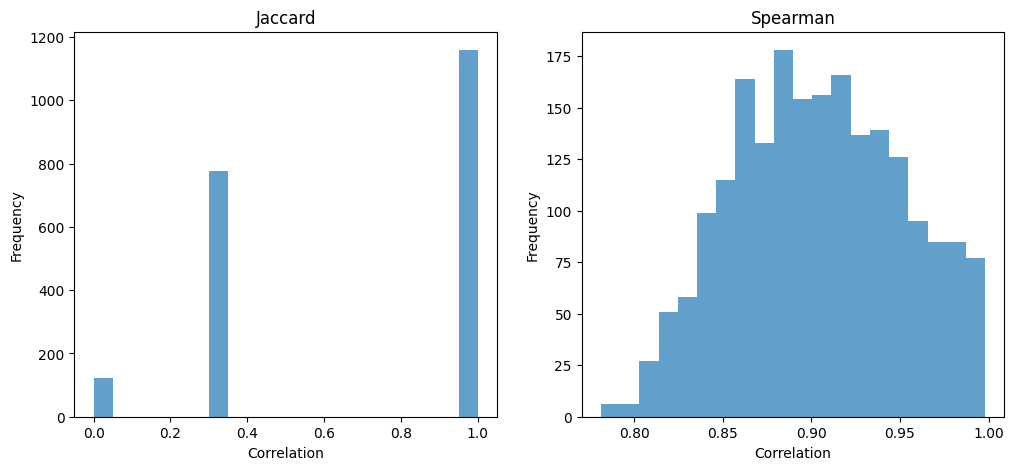

In [13]:
# Plot jaccard and Spearman correlations
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, metric, subtitle in [
    (axes[0], jaccard, "Jaccard"),
    (axes[1], spearman, "Spearman")
]:
    ax.hist(metric, bins=20, alpha=0.7)
    ax.set_xlabel("Correlation")
    ax.set_ylabel("Frequency")
    ax.set_title(subtitle)

In [10]:
def pert_rms_norm(delta: np.ndarray, top_k: int | None = None) -> np.ndarray:
    """Per-perturbation RMS norm across genes.

    If top_k is given, each perturbation row is first reduced to its top-k genes
    by absolute delta before computing the norm.
    """
    if top_k is not None:
        idx = np.argpartition(np.abs(delta), -top_k, axis=1)[:, -top_k:]
        delta = np.take_along_axis(delta, idx, axis=1)
    return np.linalg.norm(delta, axis=1) / np.sqrt(delta.shape[1])

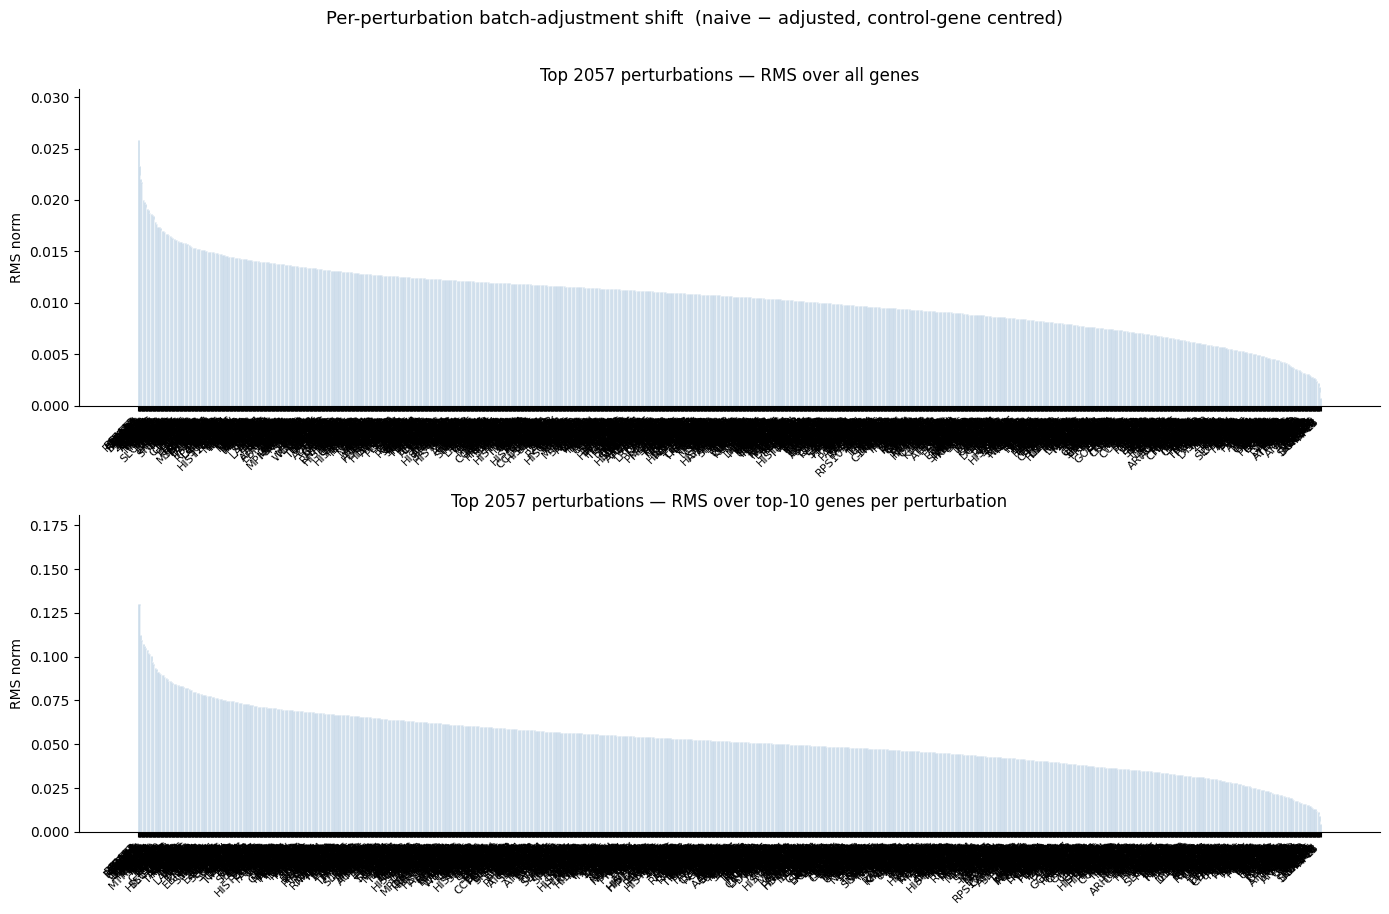

In [11]:
TOP_K_GENES = 10   # restrict RMS to top-k genes per perturbation (bottom panel)

rms_all   = pert_rms_norm(delta_matrix, top_k=None)
rms_top_k = pert_rms_norm(delta_matrix, top_k=TOP_K_GENES)

fig, axes = plt.subplots(2, 1, figsize=(14, 9))
fig.suptitle(
    "Per-perturbation batch-adjustment shift  (naive − adjusted, control-gene centred)",
    fontsize=13, y=1.01,
)

for ax, rms, subtitle in [
    (axes[0], rms_all,   f"RMS over all genes"),
    (axes[1], rms_top_k, f"RMS over top-{TOP_K_GENES} genes per perturbation"),
]:
    top_idx = np.argsort(rms)[::-1]
    ax.bar(np.arange(len(top_idx)), rms[top_idx], color="steelblue", edgecolor="white", linewidth=0.4)
    ax.set_xticks(np.arange(len(top_idx)))
    ax.set_xticklabels([pert_names[i] for i in top_idx], rotation=45, ha="right", fontsize=8)
    ax.set_ylabel("RMS norm")
    ax.set_title(f"Top {len(top_idx)} perturbations — {subtitle}")
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

## Check if B predicts T


### Empirical question 1: does B predict T?

We test the null hypothesis $H_0: B \perp\!\!\!\perp T$.

Since both $B$ (batch) and $T$ (perturbation) are categorical, we start with the contingency table:

$$N_{t,b} = \#\{i : T_i = t,\, B_i = b\}$$

and estimate the conditional and marginal batch distributions:

$$\hat{p}(B=b \mid T=t) = \frac{N_{t,b}}{N_t}, \qquad \hat{p}(B=b) = \frac{N_b}{N}$$

**Test statistic.** For each treatment level $t$, compute the total variation distance between the batch distribution within group $T=t$ and the population batch distribution:

$$\mathrm{TV}(t) = \frac{1}{2}\sum_b \bigl|\hat{p}(B=b \mid T=t) - \hat{p}(B=b)\bigr|$$

Summarise across treatment levels, weighting by $\hat{p}(T=t)$:

$$S_1 = \sum_t \hat{p}(T=t)\,\mathrm{TV}(t)$$

$S_1 = 0$ means every treatment group has the same batch distribution as the population; $S_1 = 1$ means the two are completely separated. Large $S_1$ indicates strong batch–treatment confounding.

**Permutation test.** Because $T$ has ~2000 levels the contingency table is sparse, making the chi-square approximation unreliable. We use a permutation test instead:

1. Compute observed $S_1^{\text{obs}}$.
2. Shuffle $B$ across observations; recompute $S_1$.
3. Repeat $R = 1{,}000$ times.
4. Report $p = \dfrac{1 + \#\{S_1^{\text{perm}} \geq S_1^{\text{obs}}\}}{1 + R}$ and the effect size $S_1^{\text{obs}}$.

In [32]:
def _s1(T_codes: np.ndarray, B_codes: np.ndarray, n_T: int, n_B: int) -> float:
    """Weighted mean TV distance: S1 = Σ_t p̂(T=t) TV(t)."""
    # Cast to int64 to prevent overflow in the linearised index (n_T * n_B can exceed int16 range)
    idx = T_codes.astype(np.int64) * n_B + B_codes.astype(np.int64)
    counts = np.bincount(idx, minlength=n_T * n_B).reshape(n_T, n_B).astype(np.float64)
    N = len(T_codes)
    p_T = counts.sum(axis=1) / N
    p_B = counts.sum(axis=0) / N
    p_B_given_T = counts / np.maximum(counts.sum(axis=1, keepdims=True), 1)
    tv = 0.5 * np.abs(p_B_given_T - p_B).sum(axis=1)
    return float(p_T @ tv)


# Encode categoricals as integer codes
T_cat = pd.Categorical(adata.obs["perturbation"])
B_cat = pd.Categorical(adata.obs["batch"])
T_codes = np.asarray(T_cat.codes)
B_codes = np.asarray(B_cat.codes)
n_T, n_B = len(T_cat.categories), len(B_cat.categories)

# Drop rows where either code is -1 (NaN in original column)
valid = (T_codes >= 0) & (B_codes >= 0)
if (~valid).any():
    print(f"Dropping {(~valid).sum()} observations with missing T or B")
T_codes = T_codes[valid]
B_codes = B_codes[valid]

s1_obs = _s1(T_codes, B_codes, n_T, n_B)
print(f"n_T={n_T}  n_B={n_B}  |  observed S1 = {s1_obs:.4f}")

# Permutation test
R = 5_000
rng = np.random.default_rng(42)
B_perm = B_codes.copy()
s1_perm = np.empty(R)
for r in range(R):
    rng.shuffle(B_perm)
    s1_perm[r] = _s1(T_codes, B_perm, n_T, n_B)
    if (r + 1) % 200 == 0:
        print(f"  {r+1}/{R}")

p_val = (1 + (s1_perm >= s1_obs).sum()) / (1 + R)
print(f"\nPermutation p-value : {p_val:.4g}")
print(f"Effect size  S1     : {s1_obs:.4f}")
print(f"Null range          : [{s1_perm.min():.4f}, {s1_perm.max():.4f}]")

n_T=2058  n_B=48  |  observed S1 = 0.2084
  200/5000
  400/5000
  600/5000
  800/5000
  1000/5000
  1200/5000
  1400/5000
  1600/5000
  1800/5000
  2000/5000
  2200/5000
  2400/5000
  2600/5000
  2800/5000
  3000/5000
  3200/5000
  3400/5000
  3600/5000
  3800/5000
  4000/5000
  4200/5000
  4400/5000
  4600/5000
  4800/5000
  5000/5000

Permutation p-value : 0.024
Effect size  S1     : 0.2084
Null range          : [0.2056, 0.2094]


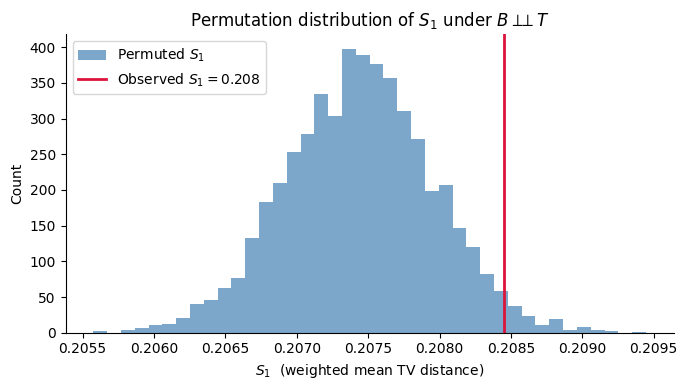

In [33]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(s1_perm, bins=40, color="steelblue", alpha=0.7, label="Permuted $S_1$")
ax.axvline(s1_obs, color="crimson", lw=2, label=f"Observed $S_1 = {s1_obs:.3f}$")
ax.set_xlabel("$S_1$  (weighted mean TV distance)")
ax.set_ylabel("Count")
ax.set_title(r"Permutation distribution of $S_1$ under $B \perp\!\!\!\perp T$")
ax.legend()
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

### Empirical question 2: does B predict Y given T?

We test $H_0: Y \perp\!\!\!\perp B \mid T$ — equivalently, $E[Y \mid T, B] = E[Y \mid T]$.

**Two models** (fitted on held-out data only):

| Model | Prediction | |
|---|---|---|
| $m_0(T)$ | $E[Y \mid T]$ | Perturbation mean |
| $m_1(T,B)$ | $E[Y \mid T, B]$ | Perturbation–batch cell mean |

Per-observation held-out squared errors:

$$L_{0i} = \|Y_i - \hat{m}_0(T_i)\|_2^2, \qquad L_{1i} = \|Y_i - \hat{m}_1(T_i, B_i)\|_2^2$$

**Test statistic** — mean improvement in prediction when batch is added:

$$S_2 = \frac{1}{n}\sum_i (L_{0i} - L_{1i})$$

| | |
|---|---|
| $S_2 > 0$ | Batch improves prediction of $Y$ beyond treatment |
| $S_2 \approx 0$ | Batch adds little outcome information given treatment |
| $S_2 < 0$ | Adding batch overfits / hurts held-out prediction |

**Cross-validation** ($K = 5$ folds). All errors are evaluated on held-out folds. When a $(T, B)$ pair is absent from the training fold, $m_1$ falls back to $m_0(T)$.

**Permutation test.** To preserve $T$ while breaking the within-$T$ relationship between $B$ and $Y$: shuffle $B$ independently within each level of $T$, refit both models under CV, recompute $S_2$. Repeat $R$ times.

> **Caveat.** Treatment groups with very few cells contribute little power — within-$T$ shuffling is a no-op for singletons. Report the effect size $S_2$ alongside the $p$-value.

In [34]:
from scipy.sparse import csr_matrix, issparse as sp_issparse


def _group_sum(codes: np.ndarray, Y: np.ndarray, n_groups: int) -> np.ndarray:
    """Sum rows of Y by integer codes; returns (n_groups, n_genes)."""
    N = len(codes)
    W = csr_matrix(
        (np.ones(N, dtype=Y.dtype),
         (codes.astype(np.int32), np.arange(N, dtype=np.int32))),
        shape=(n_groups, N),
    )
    return np.asarray(W @ Y)


def cross_val_s2(
    Y: np.ndarray,
    T_codes: np.ndarray,
    B_codes: np.ndarray,
    n_T: int,
    n_B: int,
    K: int = 5,
    fold_ids: np.ndarray | None = None,
    seed: int = 0,
) -> tuple[float, np.ndarray, np.ndarray]:
    """K-fold cross-validated S2 = mean(L0 - L1).

    m0(T) = E[Y|T],  m1(T,B) = E[Y|T,B] with fallback to m0 for unseen (T,B) pairs.
    Returns (S2, L0, L1) where L_i = squared L2 prediction error per observation.
    """
    N, G = Y.shape
    TB_codes = T_codes.astype(np.int64) * n_B + B_codes.astype(np.int64)
    n_TB = n_T * n_B

    # Full-data group sums; training sums derived by subtracting each fold
    sum_T  = _group_sum(T_codes.astype(np.int32),   Y, n_T)   # (n_T,  G)
    cnt_T  = np.bincount(T_codes.astype(int),  minlength=n_T ).astype(np.float64)
    sum_TB = _group_sum(TB_codes.astype(np.int32), Y, n_TB)   # (n_TB, G)
    cnt_TB = np.bincount(TB_codes.astype(int), minlength=n_TB).astype(np.float64)

    if fold_ids is None:
        fold_ids = np.random.default_rng(seed).integers(0, K, size=N)

    L0 = np.empty(N, dtype=np.float64)
    L1 = np.empty(N, dtype=np.float64)

    for k in range(K):
        te = np.where(fold_ids == k)[0]
        T_te, TB_te, Y_te = T_codes[te], TB_codes[te], Y[te]

        fs_T  = _group_sum(T_te.astype(np.int32),   Y_te, n_T)
        fc_T  = np.bincount(T_te.astype(int),  minlength=n_T ).astype(np.float64)
        fs_TB = _group_sum(TB_te.astype(np.int32), Y_te, n_TB)
        fc_TB = np.bincount(TB_te.astype(int), minlength=n_TB).astype(np.float64)

        tr_cnt_T  = cnt_T  - fc_T
        tr_cnt_TB = cnt_TB - fc_TB

        m0 = (sum_T  - fs_T)  / np.maximum(tr_cnt_T[:, None],  1)   # (n_T,  G)
        m1 = (sum_TB - fs_TB) / np.maximum(tr_cnt_TB[:, None], 1)   # (n_TB, G)

        m0_pred = m0[T_te]
        has_tb  = (tr_cnt_TB[TB_te] > 0)[:, None]
        m1_pred = np.where(has_tb, m1[TB_te], m0_pred)

        Y_f = Y_te.astype(np.float64)
        L0[te] = ((Y_f - m0_pred) ** 2).sum(axis=1)
        L1[te] = ((Y_f - m1_pred) ** 2).sum(axis=1)

    return float((L0 - L1).mean()), L0, L1


def _shuffle_B_within_T(T_codes: np.ndarray, B_codes: np.ndarray, rng) -> np.ndarray:
    """Permute B independently within each level of T; singletons are left unchanged."""
    B_perm = B_codes.copy()
    for t in np.unique(T_codes):
        idx = np.where(T_codes == t)[0]
        if len(idx) > 1:
            B_perm[idx] = rng.permutation(B_codes[idx])
    return B_perm

In [ ]:
# Dense float32 Y — T_codes, B_codes, n_T, n_B carried over from Q1
Y_dense = adata.X.toarray().astype(np.float32) if sp_issparse(adata.X) else np.asarray(adata.X, dtype=np.float32)
print(f"Y: {Y_dense.shape}  |  n_T={n_T}  n_B={n_B}  n_TB={n_T * n_B:,}")

K = 5
fold_ids = np.random.default_rng(0).integers(0, K, size=len(T_codes))

s2_obs, L0_obs, L1_obs = cross_val_s2(
    Y_dense, T_codes, B_codes, n_T, n_B, K=K, fold_ids=fold_ids
)
print(f"\nObserved  S2 = {s2_obs:.4f}")
print(f"  mean L0 = {L0_obs.mean():.2f}   mean L1 = {L1_obs.mean():.2f}")

# Permutation test: shuffle B within T levels (preserves T, breaks Y-B relationship)
R2 = 100
rng_perm = np.random.default_rng(1)
s2_perm  = np.empty(R2)

for r in range(R2):
    B_shuf = _shuffle_B_within_T(T_codes, B_codes, rng_perm)
    fold_r = rng_perm.integers(0, K, size=len(T_codes))
    s2_perm[r], _, _ = cross_val_s2(Y_dense, T_codes, B_shuf, n_T, n_B, K=K, fold_ids=fold_r)
    if (r + 1) % 20 == 0:
        print(f"  {r+1}/{R2}")

p_val2 = (1 + (s2_perm >= s2_obs).sum()) / (1 + R2)
print(f"\nPermutation p-value : {p_val2:.4g}")
print(f"Effect size  S2     : {s2_obs:.4f}")
print(f"Null range          : [{s2_perm.min():.4f}, {s2_perm.max():.4f}]")

Y: (310385, 5000)  |  n_T=2058  n_B=48  n_TB=98,784

Observed  S2 = -67.8707
  mean L0 = 207.48   mean L1 = 275.35


In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(s2_perm, bins=30, color="steelblue", alpha=0.7, label="Permuted $S_2$")
ax.axvline(s2_obs, color="crimson", lw=2, label=f"Observed $S_2 = {s2_obs:.3f}$")
ax.set_xlabel("$S_2$  (mean $\\ell^2$ improvement from adding batch)")
ax.set_ylabel("Count")
ax.set_title(r"Permutation distribution of $S_2$ under $Y \perp\!\!\!\perp B \mid T$")
ax.legend()
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()